<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/EWMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# df

In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/ParamAhuja/DL_Notebooks/refs/heads/main/datasets/DailyDelhiClimate.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1576 non-null   object 
 1   meantemp      1576 non-null   float64
 2   humidity      1576 non-null   float64
 3   wind_speed    1576 non-null   float64
 4   meanpressure  1576 non-null   float64
dtypes: float64(4), object(1)
memory usage: 61.7+ KB


In [7]:
df[["date", "meantemp"]].head()

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


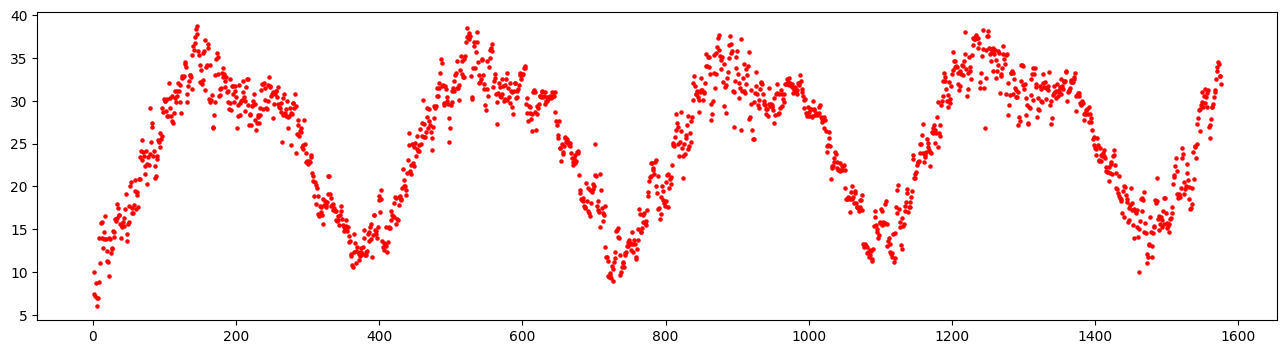

In [26]:
import matplotlib.pyplot as plt
import numpy as np
n = len(df)
x = np.arange(1, n+1)
plt.figure(figsize = (16, 4))
plt.scatter(x, df["meantemp"].values, c = "red", s=5)

# scratch

In [30]:
def ewma(data, b = 0.9):
  V_t = data.iloc[0]
  V_history = [V_t]
  for i in range(len(data)-1):
    V_t_1 = V_t
    V_t = V_t_1 * b + (1-b) * data.iloc[i + 1]
    V_history.append(V_t)
  return V_history

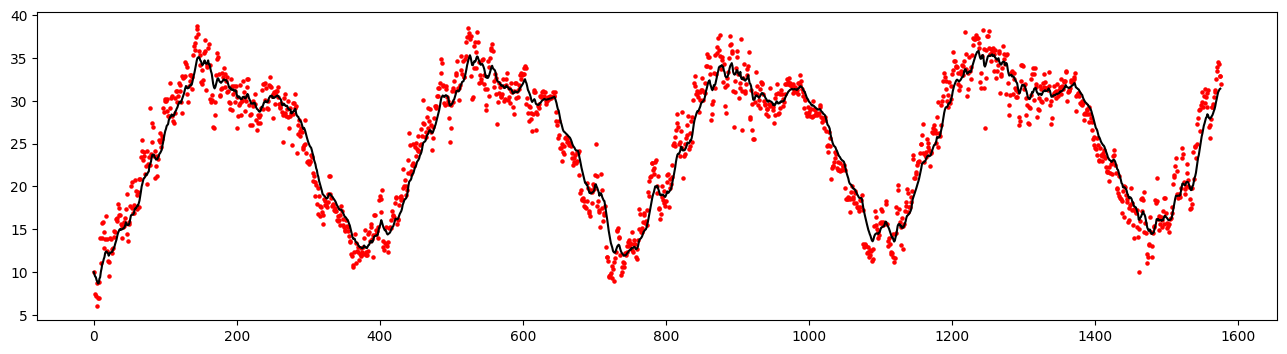

In [33]:
V_history = ewma(df["meantemp"], b = 0.9)
plt.figure(figsize = (16, 4))
plt.scatter(x, df["meantemp"].values, c = "red", s=5)
plt.plot(V_history, c = "black")

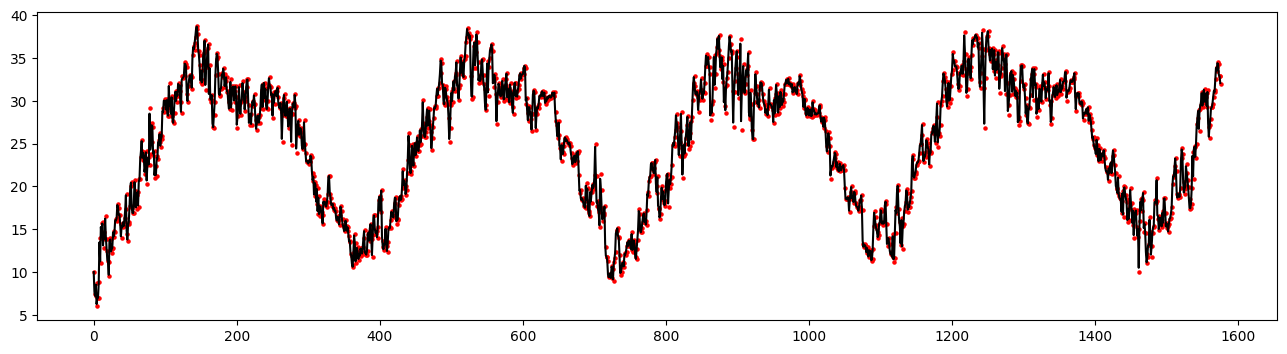

In [34]:
V_history = ewma(df["meantemp"], b = 0.1)
plt.figure(figsize = (16, 4))
plt.scatter(x, df["meantemp"].values, c = "red", s=5)
plt.plot(V_history, c = "black")

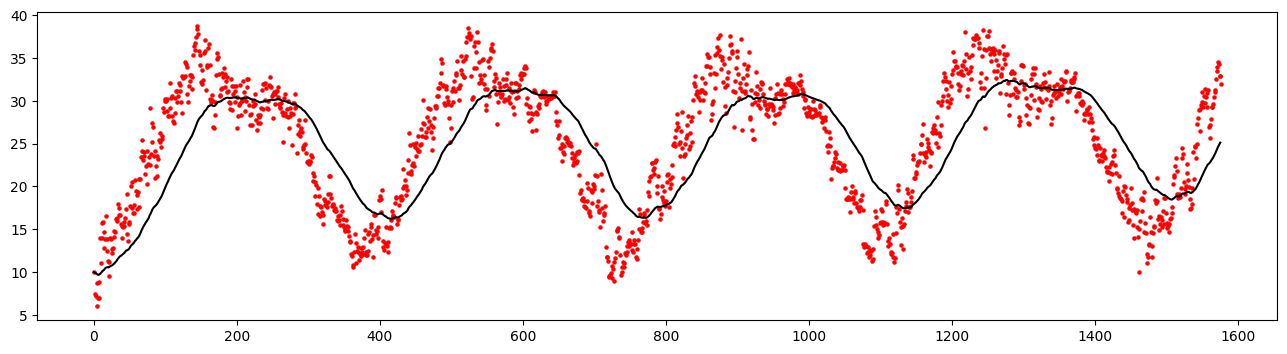

In [35]:
V_history = ewma(df["meantemp"], b = 0.98)
plt.figure(figsize = (16, 4))
plt.scatter(x, df["meantemp"].values, c = "red", s=5)
plt.plot(V_history, c = "black")

# data.ewm().mean(alpha= 1-beta)

In [41]:
V_history = df["meantemp"].ewm(alpha = 0.1).mean()

In [46]:
V_history.head()

,meantemp
0,10.000000
1,8.631579
2,8.091021
3,8.258408
4,7.706918


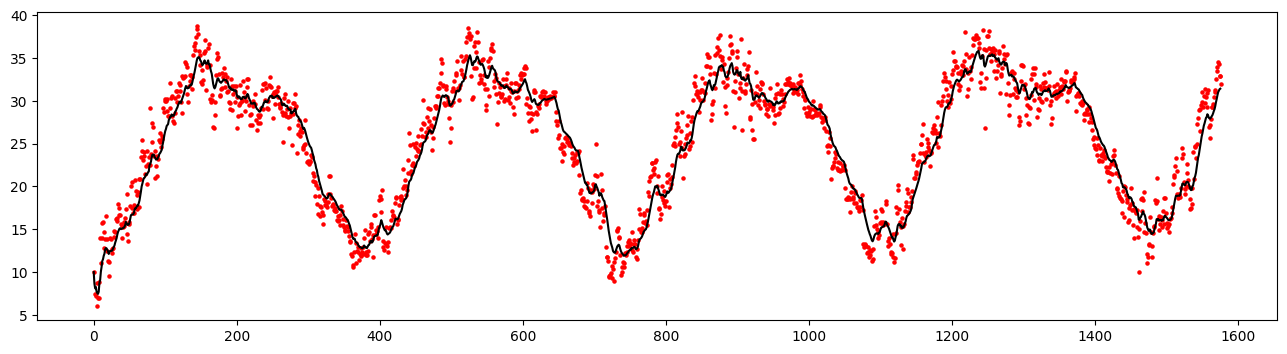

In [42]:
plt.figure(figsize = (16, 4))
plt.scatter(x, df["meantemp"].values, c = "red", s=5)
plt.plot(V_history, c = "black")

In [48]:
df["meantemp"].ewm(alpha = 0.1)

ExponentialMovingWindow [alpha=0.1,min_periods=1,adjust=True,ignore_na=False,axis=0,method=single]